In [57]:
import numpy as np

In [58]:
length = 10
n_spines = 19
layers = 2
height = 6

offset = 2 * layers + 1
num_elements = layers * (n_spines-1) # total number of elements (triangles)
num_global_nodes = offset * n_spines

We create two matrices:
$$l = \begin{bmatrix} \ell_{1,1} & \cdots & \ell_{1,6} \\ \vdots & \ddots & \vdots \\ \ell_{i,1} & \cdots & \ell_{i,6} \end{bmatrix}_{i \times 6}$$
where $i$ is the total number of elements. Each element has 6 local nodes.
$$s =  \begin{bmatrix} c_{1,1} &  c_{1,2} \\ \vdots & \vdots \\ c_{k,1}  & c_{k,2} \end{bmatrix}_{k \times 2}$$
where $k$ is the total number of global nodes.

In [59]:
l = [[0] * 6] * num_elements
s = [[0, 0]] * num_global_nodes

In [60]:
for el in range(0, num_elements, 2):
    col = el // (2 * layers) # each column pair has 2m elements
    row = el % (2 * layers)
    start = col * 2 * offset + row

    l[el] = [start,
            start + 2 * offset,
            start + 2 * offset + 2,
            start + offset + 1,
            start + offset,
            start + 2 * offset + 1]
    
    l[el + 1] = [start,
                start + 2 * offset + 2,
                start + 2,
                start + 1,
                start + offset + 1,
                start + offset + 2]

for row in l:
    print(row)

[0, 10, 12, 6, 5, 11]
[0, 12, 2, 1, 6, 7]
[2, 12, 14, 8, 7, 13]
[2, 14, 4, 3, 8, 9]
[10, 20, 22, 16, 15, 21]
[10, 22, 12, 11, 16, 17]
[12, 22, 24, 18, 17, 23]
[12, 24, 14, 13, 18, 19]
[20, 30, 32, 26, 25, 31]
[20, 32, 22, 21, 26, 27]
[22, 32, 34, 28, 27, 33]
[22, 34, 24, 23, 28, 29]
[30, 40, 42, 36, 35, 41]
[30, 42, 32, 31, 36, 37]
[32, 42, 44, 38, 37, 43]
[32, 44, 34, 33, 38, 39]
[40, 50, 52, 46, 45, 51]
[40, 52, 42, 41, 46, 47]
[42, 52, 54, 48, 47, 53]
[42, 54, 44, 43, 48, 49]
[50, 60, 62, 56, 55, 61]
[50, 62, 52, 51, 56, 57]
[52, 62, 64, 58, 57, 63]
[52, 64, 54, 53, 58, 59]
[60, 70, 72, 66, 65, 71]
[60, 72, 62, 61, 66, 67]
[62, 72, 74, 68, 67, 73]
[62, 74, 64, 63, 68, 69]
[70, 80, 82, 76, 75, 81]
[70, 82, 72, 71, 76, 77]
[72, 82, 84, 78, 77, 83]
[72, 84, 74, 73, 78, 79]
[80, 90, 92, 86, 85, 91]
[80, 92, 82, 81, 86, 87]
[82, 92, 94, 88, 87, 93]
[82, 94, 84, 83, 88, 89]


In [61]:
def spine_height(i):
    '''
    A sine wave function that takes in ith spine (horizontally) and returns its height
    '''
    if i < n_spines:
        x_coord = i * length / (n_spines - 1)
        return height + np.sin(x_coord) # height of the spine varies around the initial height

In [62]:
for gn in range(num_global_nodes):
    col, row = gn // offset, gn % offset
    h = spine_height(col)
    s[gn] = (col * length / (n_spines - 1), row / (2 * layers) * h)
s

# but sine wave is a continuous function, while my choices are discrete

[(0.0, np.float64(0.0)),
 (0.0, np.float64(1.5)),
 (0.0, np.float64(3.0)),
 (0.0, np.float64(4.5)),
 (0.0, np.float64(6.0)),
 (0.5555555555555556, np.float64(0.0)),
 (0.5555555555555556, np.float64(1.6318538464429664)),
 (0.5555555555555556, np.float64(3.2637076928859328)),
 (0.5555555555555556, np.float64(4.895561539328899)),
 (0.5555555555555556, np.float64(6.5274153857718655)),
 (1.1111111111111112, np.float64(0.0)),
 (1.1111111111111112, np.float64(1.724048050257489)),
 (1.1111111111111112, np.float64(3.448096100514978)),
 (1.1111111111111112, np.float64(5.172144150772468)),
 (1.1111111111111112, np.float64(6.896192201029956)),
 (1.6666666666666667, np.float64(0.0)),
 (1.6666666666666667, np.float64(1.7488519894379413)),
 (1.6666666666666667, np.float64(3.4977039788758826)),
 (1.6666666666666667, np.float64(5.246555968313824)),
 (1.6666666666666667, np.float64(6.995407957751765)),
 (2.2222222222222223, np.float64(0.0)),
 (2.2222222222222223, np.float64(1.6988050142557622)),
 (2.222

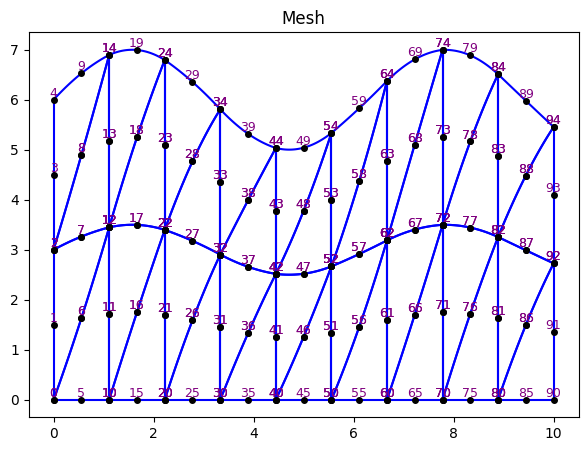

In [65]:
import matplotlib.pyplot as plt

def plot():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_aspect('equal')

    xi = np.linspace(-1, 1, 40)
    phi_l, phi_m, phi_r = xi * (xi - 1) / 2, 1 - xi**2, xi * (xi + 1) / 2

    def plot_edge(l, m, r):
        xl, yl = s[l]
        xm, ym = s[m]
        xr, yr = s[r]
        ax.plot(xl*phi_l + xm*phi_m + xr*phi_r, yl*phi_l + ym*phi_m + yr*phi_r, color='b')

    xs = [coord[0] for coord in s]
    ys = [coord[1] for coord in s]

    for nodes in l:
        for (a, b), mid in {(0,1): 4, (1,2): 5, (2,0): 3}.items():
            plot_edge(nodes[a], nodes[mid], nodes[b])
            
        for gn in nodes:
            ax.plot(xs[gn], ys[gn], 'ko', ms=4)
            ax.text(xs[gn], ys[gn], str(gn), fontsize=9, ha='center', va='bottom', color='purple')

    ax.set_title('Mesh')
    plt.show()


plot()


TODO: update
$$\psi_1 = \frac{1 + \eta}{2}$$

$$\psi_2 = -\frac{\xi + \eta}{2}$$

$$\psi_3 = \frac{1 + \xi}{2}$$

$$\phi_1 = \psi_1(2\psi_1 - 1) = \frac{1 + \eta}{2}(1 + \eta - 1) = \frac{\eta(\eta + 1)}{2} = \frac{\eta^2 + \eta}{2}$$

$$\phi_2 = \psi_2(2\psi_2 - 1) = -\frac{\xi + \eta}{2}(-\xi - \eta - 1) = \frac{(\xi + \eta)(\xi + \eta + 1)}{2} = \frac{\xi^2 + \eta^2 + 2\xi\eta + \xi + \eta}{2}$$

$$\phi_3 = \psi_3(2\psi_3 - 1) = \frac{1 + \xi}{2}(1 + \xi - 1) = \frac{\xi(\xi + 1)}{2} = \frac{\xi^2 + \xi}{2}$$

In [64]:
def shape_functions(xi, eta):
    '''
    6 quadratic shape functions
    '''
    psi1 = (1 + eta) / 2
    psi2 = -(xi + eta) / 2
    psi3 = (1 + xi) / 2

    phi = np.zeros(6)
    phi[0] = psi2 * (2*psi2 - 1)
    phi[1] = psi3 * (2*psi3 - 1)
    phi[2] = psi1 * (2*psi1 - 1)
    phi[3] = 4 * psi1 * psi2
    phi[4] = 4 * psi2 * psi3
    phi[5] = 4 * psi1 * psi3

    return phi